In [1]:
tr_path='covid.train.csv'
tt_path='covid.test.shuffle.csv'

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader

import numpy as np
import csv
import os
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

myseed=42069
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False

np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

In [3]:
config={
    'n_epochs':3000,
    'batch_size':100,
    'optimizer':'SGD',
    # 'optimizer':'Adam',
    'optim_hparas':{
        'lr':0.01,
        'momentum':0.9
    },
    'early_stop':200,
    'save_path':'models/model.pth'
}

In [4]:
def get_device():
    return 'cuda' if torch.cuda.is_available() else 'cpu'
def plot_learning_curve(loss_record,title=''):
    x_1=range(len(loss_record['train']))
    x_2=x_1[::len(loss_record['train'])//len(loss_record['dev'])]
    figure(figure=(6,4))
    plt.plot(x_1,loss_record['train'],c='tab:red',label='train')
    plt.plot(x_2,loss_record['dev'],c='tab:cyan',label='dev')
    plt.ylim(0.0,5)
    plt.xlabel('Training steps')
    plt.ylabel('MSE loss')
    plt.title(f'Learning curve of {title}')
    plt.legend()
    plt.show()
def plot_pred(dv_set,model,device,lim=35.,preds=None,targets=None):
    if preds is None or targets is None:
        model.eval()
        preds,targets=[],[]
        for x,y in dv_set:
            x,y=x.to(device),y.to(device)
            with torch.no_grad():
                pred=model(x)
                preds.append(pred.detach().cpu())
                targets.append(y.detach().cpu())
        preds=torch.cat(preds,dim=0).numpy()
        targets=torch.cat(targets,dim=0).numpy()
    figure(figsize=(5,5))
    plt.scatter(targets,preds,c='r',alpha=0.5)
    plt.plot([-0.2,lim],[-0.2,lim],c='b')
    plt.xlim(-0.2,lim)
    plt.ylim(-0.2,lim)
    plt.xlabel('truth value')
    plt.ylabel('predicted value')
    plt.title('Truth v.s. Prediction')
    plt.show()

In [5]:
def get_feats(tr_path):
    df = pd.read_csv(tr_path)
    target_column = 94
    top_key  = 20
    
    y = df.iloc[:,target_column]
    X = df.drop(columns=df.columns[target_column])
    
    # print(y)
    correlations = X.corrwith(y).abs().sort_values(ascending=False).head(top_key)
    # print(correlations)
    selected_features = [df.columns.get_loc(i) - 1 for i in correlations.index]
    return selected_features
    # print("Selected features:\n", selected_features)
feats=get_feats(tr_path)
print(feats)

[75, 57, 42, 60, 78, 43, 61, 79, 40, 58, 76, 41, 59, 77, 92, 74, 56, 87, 69, 51]


In [6]:
class COVID19Dataset(Dataset):
    def __init__(self,path,mode='train',target_only=False):
        self.mode=mode
        with open(path,'r') as fp:
            data=list(csv.reader(fp))
            data=np.array(data[1:])[:,1:].astype(float)
        if not target_only:
            feats=list(range(93))
        else:
            # feats=list(range(40))+get_feats(tr_path) 
            # feats=list(range(40))+[57,75]
            feats=[75, 57, 42, 60, 78, 43, 61, 79, 40, 58, 76, 41, 59, 77, 92, 74, 56, 87, 69, 51]

        if mode=='test':
            data=data[:,feats]
            self.data=torch.FloatTensor(data)
        else:
            target=data[:,-1]
            data=data[:,feats]
            if mode=='train':
                indices=[i for i in range(len(data)) if i %15 !=0]
            elif mode=='dev':
                indices=[i for i in range(len(data)) if i%15 == 0]
            self.data=torch.FloatTensor(data[indices])
            self.target=torch.FloatTensor(target[indices])
            
        # self.data[:,40:]=(self.data[:,40:]-self.data[:,40:].mean(dim=0,keepdim=True))\
        # /self.data[:,40:].std(dim=0,keepdim=True)

        self.data=(self.data-self.data.mean(dim=0,keepdim=True))\
        /self.data.std(dim=0,keepdim=True)
        
        print(f'{mode} set:{len(self.data)} samples,{self.data.shape[1]} dim')

    def __getitem__(self,index):
        if self.mode in ['train','dev']:
            return self.data[index],self.target[index]
        else:
            return self.data[index]

    def __len__(self):
        return len(self.data)

In [7]:
def prep_dataloader(path,mode,batch_size,n_jobs=0,target_only=False):
    dataset=COVID19Dataset(path,mode=mode,target_only=target_only)
    dataloader=DataLoader(
        dataset,batch_size,
        shuffle=(mode=='train'),drop_last=False,
        num_workers=n_jobs,pin_memory=True
    )
    return dataloader

In [8]:
class NeuralNet(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(input_dim,8),
            nn.BatchNorm1d(8),
            nn.Dropout(p=0.2),
            nn.ReLU(),
            nn.Linear(8,1)
        )

        self.criterion=nn.MSELoss(reduction='mean')
    def forward(self,x):
        return self.net(x).squeeze(1)
    def cal_loss(self,pred,target):
        regularization_loss = 0
        for param in model.parameters():
            regularization_loss += torch.sum(param ** 2)
        return self.criterion(pred, target) + 0.0005 * regularization_loss
        

In [9]:
def train(tr_set,dev_set,model,config,device):
    n_epochs=config['n_epochs']
    optimizer=getattr(torch.optim,config['optimizer'])(
        model.parameters(),**config['optim_hparas']
    )
    min_mse=1000.
    epoch=0
    early_stop_cnt=0
    loss_record={'train':[],'dev':[]}
    while epoch<n_epochs:
        model.train()
        for x,y in tr_set:
            optimizer.zero_grad()
            x,y=x.to(device),y.to(device)
            pred=model(x)
            mse_loss=model.cal_loss(pred,y)
            mse_loss.backward()
            optimizer.step()
            loss_record['train'].append(mse_loss.detach().cpu().item())
        dev_mse=dev(dv_set,model,device)
        if dev_mse<min_mse:
            min_mse=dev_mse
            print(f'{epoch+1} epoch :loss>>{min_mse}')
            torch.save(model.state_dict(),config['save_path'])
            early_stop_cnt=0
        else:
            early_stop_cnt+=1
        epoch+=1
        loss_record['dev'].append(dev_mse)
        if early_stop_cnt>config['early_stop']:
            break
    print(f'Finished training after {epoch}')
    return min_mse,loss_record
            
            

In [10]:
def dev(dv_set, model, device):
    model.eval()                                # set model to evalutation mode
    total_loss = 0
    for x, y in dv_set:                         # iterate through the dataloader
        x, y = x.to(device), y.to(device)       # move data to device (cpu/cuda)
        with torch.no_grad():                   # disable gradient calculation
            pred = model(x)                     # forward pass (compute output)
            mse_loss = model.cal_loss(pred, y)  # compute loss
        total_loss += mse_loss.detach().cpu().item() * len(x)  # accumulate loss
    total_loss = total_loss / len(dv_set.dataset)              # compute averaged loss

    return total_loss

In [11]:
def test(tt_set,model,device):
    model.eval()
    preds=[]
    for x in tt_set:
        x=x.to(device)
        with torch.no_grad():
            pred=model(x)
        preds.append(pred.detach().cpu())
    preds=torch.cat(preds,dim=0).numpy()
    return preds

In [12]:
device=get_device()
os.makedirs('models',exist_ok=True)
target_only=True

In [13]:
tr_set = prep_dataloader(tr_path, 'train', config['batch_size'], target_only=target_only)
dv_set = prep_dataloader(tr_path, 'dev', config['batch_size'], target_only=target_only)
tt_set = prep_dataloader(tt_path, 'test', config['batch_size'], target_only=target_only)

train set:2520 samples,20 dim
dev set:180 samples,20 dim
test set:893 samples,20 dim


In [14]:
print(tr_set.dataset.data.shape)  # 输出形如 (n_samples, n_features)
# 查看dim=0的大小（样本数）：
print(f"样本数量：{tr_set.dataset.data[:,40:].size(0)}")

torch.Size([2520, 20])
样本数量：2520


In [15]:
model=NeuralNet(tr_set.dataset.data.shape[1]).to(device)

In [16]:
model_loss,model_loss_record=train(tr_set,dv_set,model,config,device)

1 epoch :loss>>21.214442994859482
2 epoch :loss>>3.8657080862257214
3 epoch :loss>>3.6568220456441245
4 epoch :loss>>3.531884776221381
7 epoch :loss>>2.1346817281511097
14 epoch :loss>>2.032377587424384
19 epoch :loss>>1.6621430979834662
37 epoch :loss>>1.4491823249393039
43 epoch :loss>>1.3422970506880019
44 epoch :loss>>1.3253249989615545
113 epoch :loss>>1.245872312121921
154 epoch :loss>>1.1458206441667345
204 epoch :loss>>1.1183170477549236
366 epoch :loss>>1.0798040231068928
506 epoch :loss>>1.0700600677066379
Finished training after 707


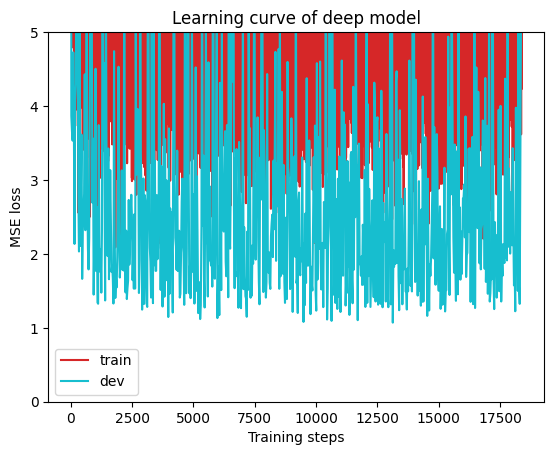

In [17]:
plot_learning_curve(model_loss_record, title='deep model')

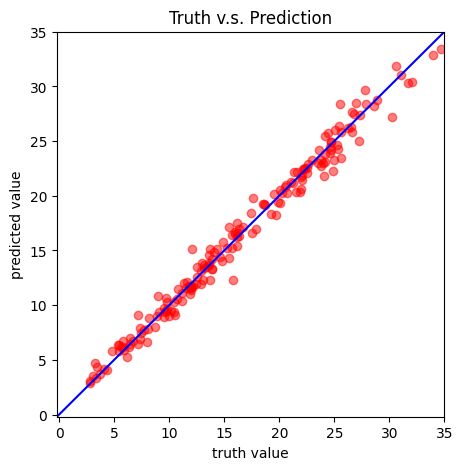

In [18]:
del model
model = NeuralNet(tr_set.dataset.data.shape[1]).to(device)
ckpt = torch.load(config['save_path'], map_location='cpu')  # Load your best model
model.load_state_dict(ckpt)
plot_pred(dv_set, model, device)  # Show prediction on the validation set

In [19]:
def save_pred(preds, file):
    ''' Save predictions to specified file '''
    print('Saving results to {}'.format(file))
    with open(file, 'w') as fp:
        writer = csv.writer(fp)
        writer.writerow(['id', 'tested_positive'])
        for i, p in enumerate(preds):
            writer.writerow([i, p])

preds = test(tt_set, model, device)  # predict COVID-19 cases with your model
save_pred(preds, 'pred.csv')         # save prediction file to pred.csv

Saving results to pred.csv
